In [2]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import root_mean_squared_error, r2_score

import warnings

warnings.filterwarnings(
    "ignore", category=DeprecationWarning
)  # to avoid deprecation warnings

In [3]:
# Lecture des fichiers
print("Loading dataset...")
dataset = pd.read_csv("Walmart_Store_sales.csv")
print("...Done.")

Loading dataset...
...Done.


# Analyse descriptive

In [ ]:
# INFORMATIONS GENERALES
print("\n INFORMATIONS GENERALES")
print("-"*40)

print("Nombre de lignes : {}".format(dataset.shape[0]))
print("Nombre de colonnes : {}".format(dataset.shape[1]))
print("Nombre de magasins : {}".format(dataset['Store'].nunique()))

# Date : conversion de la colonne Date en format datetime
dataset['Date'] = pd.to_datetime(dataset['Date'], errors='coerce', dayfirst=True)
#  Afficher la plage des dates avec les heures
print("Période couverte: {} - {}".format(dataset['Date'].min(), dataset['Date'].max()))

print("Aperçu du dataset : ")
display(dataset.head())

print("Types de données/colonnes : ")
display(dataset.dtypes)



 INFORMATIONS GENERALES
----------------------------------------
Nombre de lignes : 150
Nombre de colonnes : 8
Nombre de magasins : 20
Période couverte: 2010-02-05 00:00:00 - 2012-10-19 00:00:00
Aperçu du dataset : 


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,2011-02-18,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,2011-03-25,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,2012-07-27,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaT,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,2010-05-28,1644470.66,0.0,78.89,2.759,212.412888,7.092


Types de données/colonnes : 


Store                  float64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag           float64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

In [146]:
# VALEURS MANQUANTES
print("\n VALEURS MANQUANTES")
print("-"*40)

print("Nombre de valeurs manquantes par colonne :")
missing_values = dataset.isnull().sum()
missing_values_percentage = ((missing_values / dataset.shape[0]) * 100).round(2)
missing_df = pd.DataFrame({
    "Valeurs manquantes": missing_values,
    "Pourcentage": missing_values_percentage
})
display(missing_df[missing_df["Valeurs manquantes"] > 0])



 VALEURS MANQUANTES
----------------------------------------
Nombre de valeurs manquantes par colonne :


,Valeurs manquantes,Pourcentage
Date,18,12.00
Weekly_Sales,14,9.33
Holiday_Flag,12,8.00
Temperature,18,12.00
Fuel_Price,14,9.33
CPI,12,8.00
Unemployment,15,10.00


In [147]:
# Conversion Fahrenheit -> Celsius
dataset['Temperature_C'] = (dataset['Temperature'] - 32) * 5/9
dataset['Temperature_C'] = dataset['Temperature_C'].round(2)

# Convertir Date en année / semaine / jour de semaine
dataset['Year'] = dataset['Date'].dt.year
dataset['Month'] = dataset['Date'].dt.month
dataset['Day'] = dataset['Date'].dt.day
dataset['Weekday'] = dataset['Date'].dt.weekday # 0 = Lundi, 6 = Dimanche

# Convertir Store en int
dataset['Store'] = dataset['Store'].astype(int)

print("Types de données/colonnes : ")
display(dataset.dtypes)


Types de données/colonnes : 


Store                     int64
Date             datetime64[ns]
Weekly_Sales            float64
Holiday_Flag            float64
Temperature             float64
Fuel_Price              float64
CPI                     float64
Unemployment            float64
Temperature_C           float64
Year                    float64
Month                   float64
Day                     float64
Weekday                 float64
dtype: object

In [ ]:
# STATISTIQUES DESCRIPTIVES

# Statistiques descriptives globales
print("Statistiques descriptives globales :")
display(dataset.describe(include="all").round(2))


Statistiques descriptives globales :


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Temperature_C,Year,Month,Day,Weekday
count,150.00,132,136.00,138.00,132.00,136.00,138.00,135.00,132.00,132.00,132.00,132.00,132.0
mean,9.87,2011-05-07 09:05:27.272727296,1249535.83,0.08,61.40,3.32,179.90,7.60,16.33,2010.86,6.39,16.52,4.0
min,1.00,2010-02-05 00:00:00,268929.03,0.00,18.79,2.51,126.11,5.14,-7.34,2010.00,1.00,1.00,4.0
25%,4.00,2010-08-16 12:00:00,605075.72,0.00,45.59,2.85,131.97,6.60,7.55,2010.00,4.00,10.00,4.0
50%,9.00,2011-05-09 12:00:00,1261423.86,0.00,62.98,3.45,197.91,7.47,17.22,2011.00,6.00,17.00,4.0
75%,15.75,2012-01-14 18:00:00,1806386.20,0.00,76.34,3.71,214.93,8.15,24.63,2012.00,9.00,24.00,4.0
max,20.00,2012-10-19 00:00:00,2771397.17,1.00,91.65,4.19,226.97,14.31,33.14,2012.00,12.00,31.00,4.0
std,6.23,NaN,647463.04,0.27,18.38,0.48,40.27,1.58,10.21,0.81,3.21,8.31,0.0


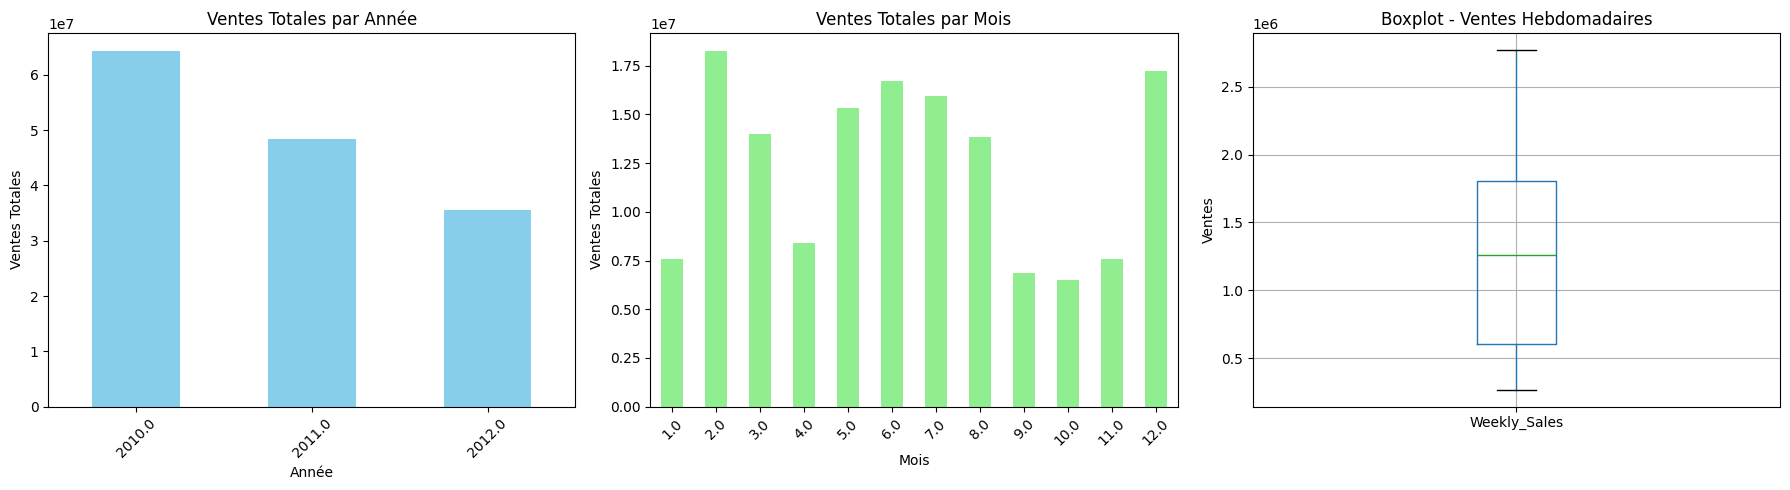

In [149]:
# Création d'une figure avec 3 sous-graphes sur une ligne
fig, axes = plt.subplots(1, 3, figsize=(18,5))  # 1 ligne, 3 colonnes

# Ventes Totales par Année
dataset.groupby('Year')['Weekly_Sales'].sum().plot(kind='bar', color='skyblue', ax=axes[0])
axes[0].set_title('Ventes Totales par Année')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Ventes Totales')
axes[0].tick_params(axis='x', rotation=45)

# Ventes Totales par Mois
dataset.groupby('Month')['Weekly_Sales'].sum().plot(kind='bar', color='lightgreen', ax=axes[1])
axes[1].set_title('Ventes Totales par Mois')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('Ventes Totales')
axes[1].tick_params(axis='x', rotation=45)

# Boxplot - Ventes Hebdomadaires
dataset.boxplot(column='Weekly_Sales', ax=axes[2])
axes[2].set_title('Boxplot - Ventes Hebdomadaires')
axes[2].set_ylabel('Ventes')

# Ajustement pour que les éléments ne se chevauchent pas
plt.tight_layout()
plt.show()


Nombre de magasins ayant au moins un jour férié : 8
Pourcentage de magasins concernés : 40.00%


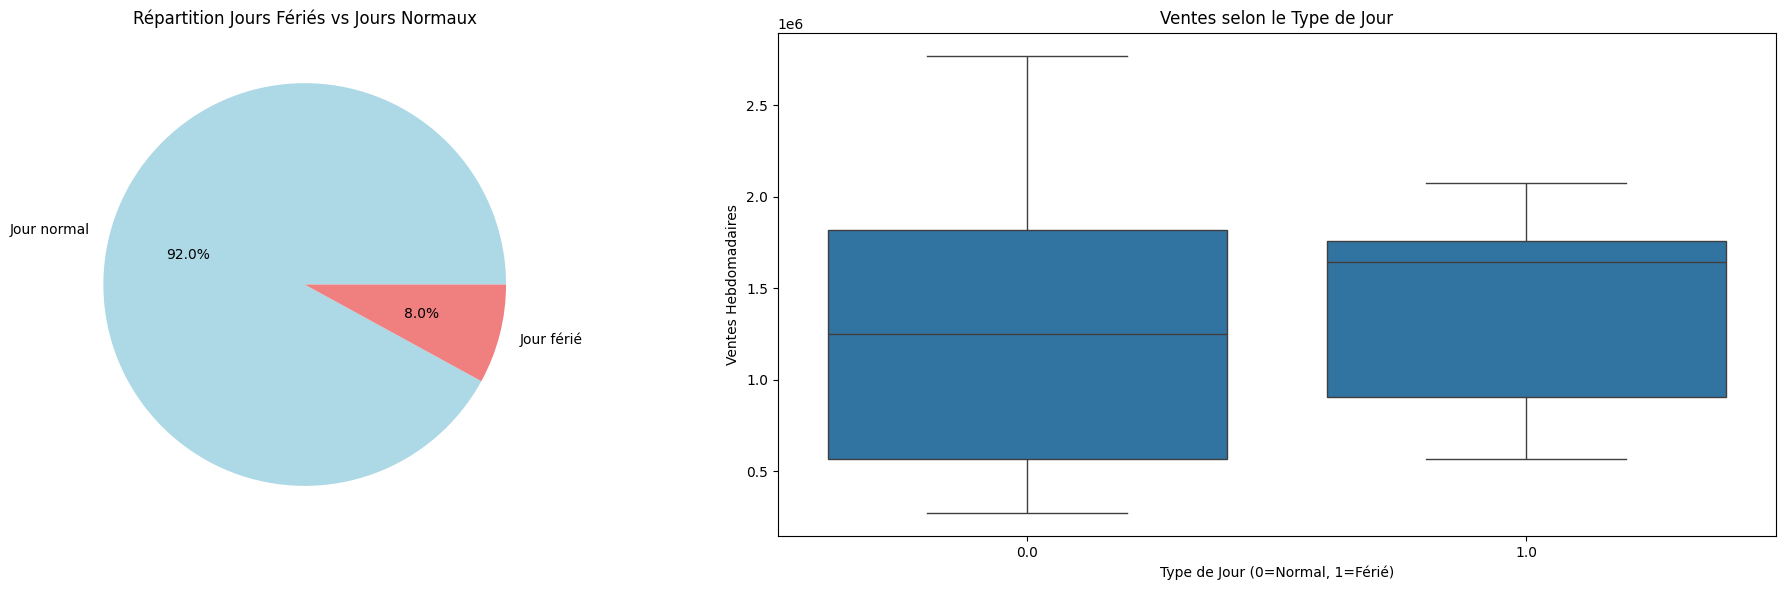

In [150]:
# Création de la figure avec 3 sous-graphes
fig, axes = plt.subplots(1, 2, figsize=(20,6))  # 1 ligne, 3 colonnes

# Nombre total de magasins
total_stores = dataset['Store'].nunique()
# Nombre de magasins avec au moins un jour férié
stores_with_holiday = dataset[dataset['Holiday_Flag'] == 1]['Store'].nunique()
# Pourcentage
percent_with_holiday = (stores_with_holiday / total_stores) * 100

print(f"Nombre de magasins ayant au moins un jour férié : {stores_with_holiday}")
print(f"Pourcentage de magasins concernés : {percent_with_holiday:.2f}%")

# Répartition Jours Fériés vs Jours Normaux (pie chart)
holiday_counts = dataset['Holiday_Flag'].value_counts()
axes[0].pie(holiday_counts.values, labels=['Jour normal', 'Jour férié'], autopct='%1.1f%%',
            colors=['lightblue', 'lightcoral'])
axes[0].set_title('Répartition Jours Fériés vs Jours Normaux')

# Ventes selon le type de jour (boxplot)
sns.boxplot(data=dataset, x='Holiday_Flag', y='Weekly_Sales', ax=axes[1])
axes[1].set_title('Ventes selon le Type de Jour')
axes[1].set_xlabel('Type de Jour (0=Normal, 1=Férié)')
axes[1].set_ylabel('Ventes Hebdomadaires')


# Ajustement des espaces
plt.tight_layout()
plt.show()

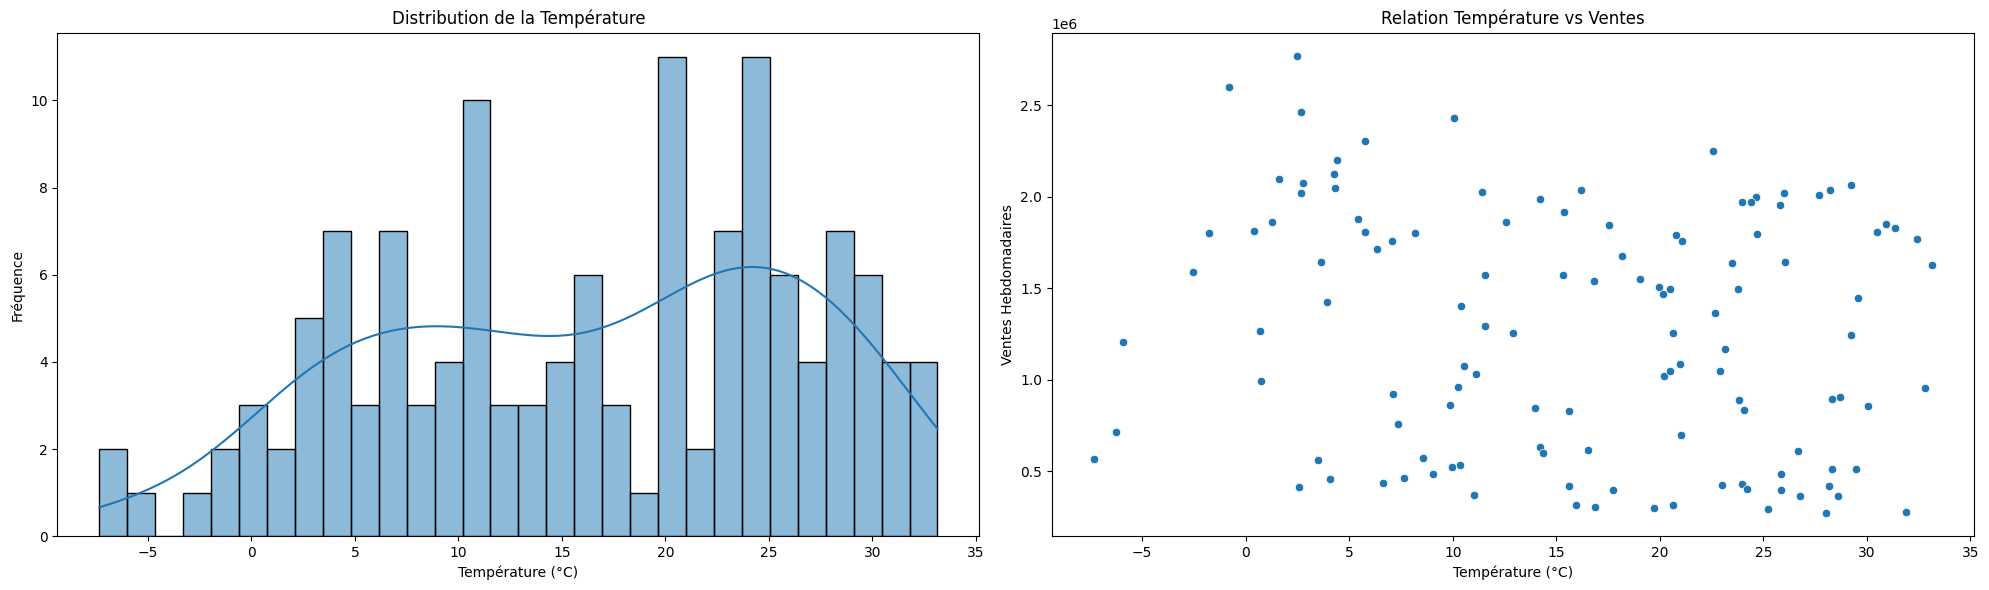

In [151]:
# Création de la figure avec 2 sous-graphes
fig, axes = plt.subplots(1, 2, figsize=(20,6))  # 1 ligne, 2 colonnes

# Distribution de la température
sns.histplot(data=dataset, x='Temperature_C', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution de la Température')
axes[0].set_xlabel('Température (°C)')
axes[0].set_ylabel('Fréquence')

# Températures vs ventes hebdomadaires
sns.scatterplot(data=dataset, x='Temperature_C', y='Weekly_Sales', ax=axes[1])
axes[1].set_title('Relation Température vs Ventes')
axes[1].set_xlabel('Température (°C)')
axes[1].set_ylabel('Ventes Hebdomadaires')

# Ajustement des espaces
plt.tight_layout()
plt.show()

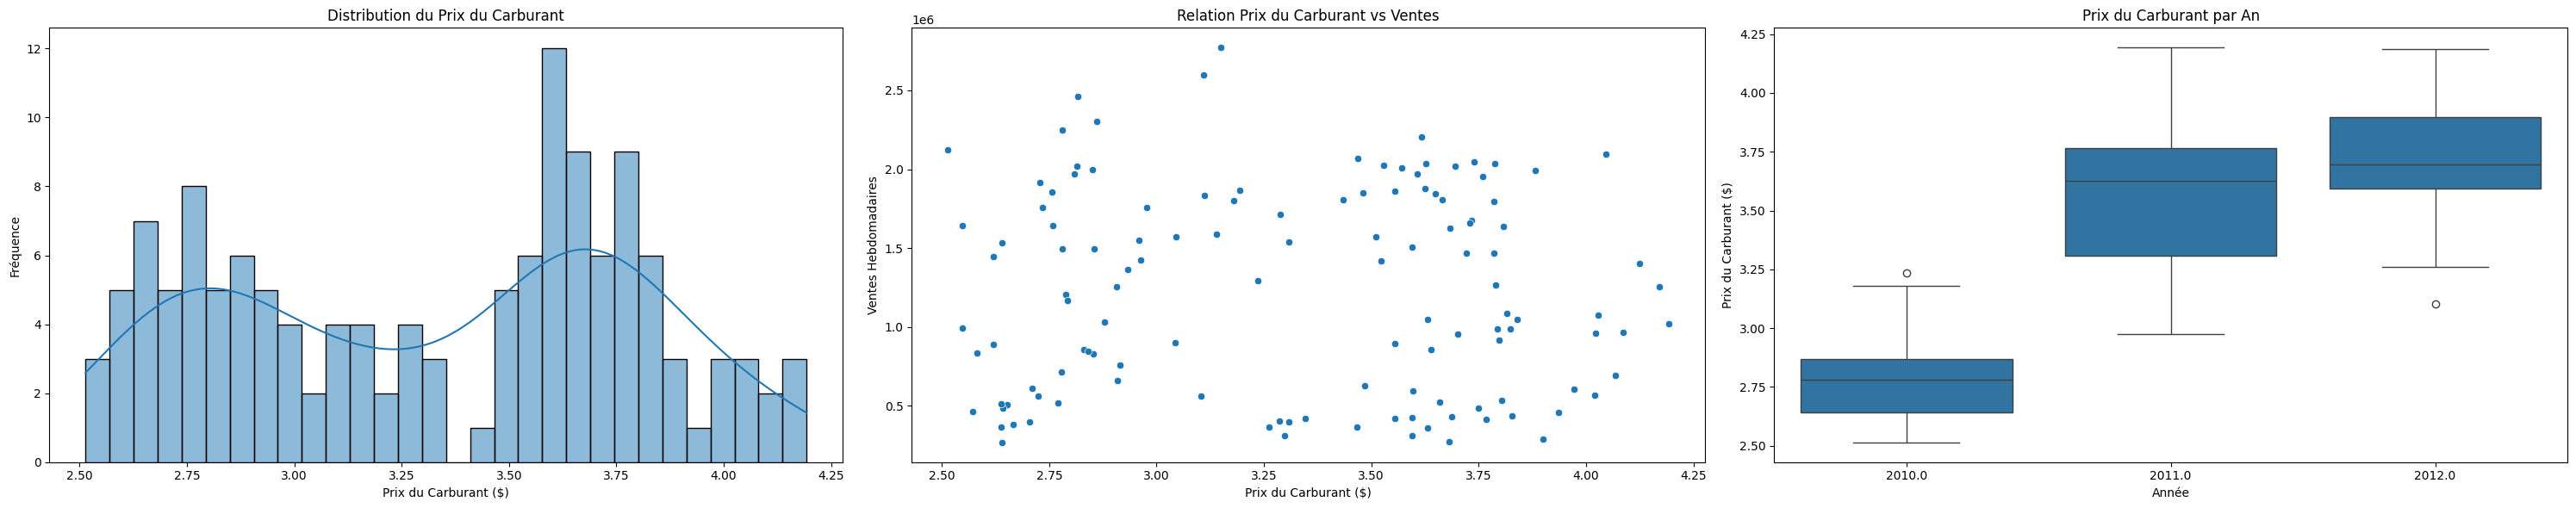

In [152]:
# Création de la figure avec 3 sous-graphes
fig, axes = plt.subplots(1, 3, figsize=(30,6))  # 1 ligne, 3 colonnes

# Distribution Prix du Carburant
sns.histplot(data=dataset, x='Fuel_Price', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution du Prix du Carburant')
axes[0].set_xlabel('Prix du Carburant ($)')
axes[0].set_ylabel('Fréquence')

# Prix du Carburant vs ventes hebdomadaires
sns.scatterplot(data=dataset, x='Fuel_Price', y='Weekly_Sales', ax=axes[1])
axes[1].set_title('Relation Prix du Carburant vs Ventes')
axes[1].set_xlabel('Prix du Carburant ($)')
axes[1].set_ylabel('Ventes Hebdomadaires')

# Prix du carburant vs mois
sns.boxplot(data=dataset, x='Year', y='Fuel_Price', ax=axes[2])
axes[2].set_title('Prix du Carburant par An')
axes[2].set_xlabel('Année')
axes[2].set_ylabel('Prix du Carburant ($)')

# Ajustement des espaces
plt.tight_layout()
plt.show()

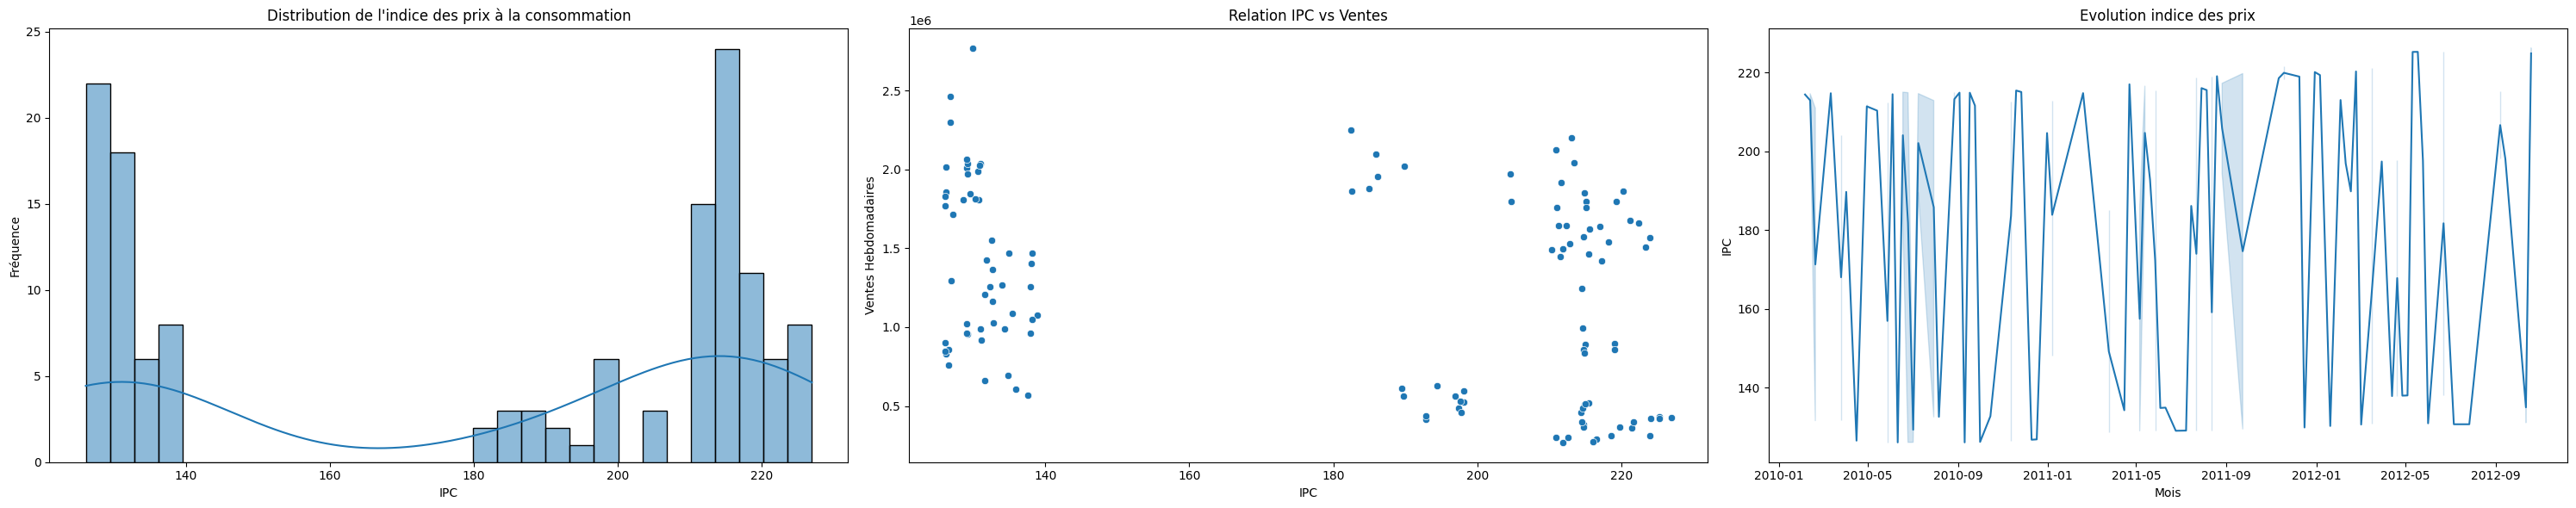

In [153]:
# Création de la figure avec 3 sous-graphes
fig, axes = plt.subplots(1, 3, figsize=(30,6))  # 1 ligne, 3 colonnes

# Distribution IPC
sns.histplot(data=dataset, x='CPI', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution de l\'indice des prix à la consommation')
axes[0].set_xlabel('IPC')
axes[0].set_ylabel('Fréquence')

# IPC vs ventes hebdomadaires
sns.scatterplot(data=dataset, x='CPI', y='Weekly_Sales', ax=axes[1])
axes[1].set_title('Relation IPC vs Ventes')
axes[1].set_xlabel('IPC')
axes[1].set_ylabel('Ventes Hebdomadaires')

# IPC vs date
sns.lineplot(data=dataset, x='Date', y='CPI', ax=axes[2])
axes[2].set_title('Evolution indice des prix')
axes[2].set_xlabel('Mois')
axes[2].set_ylabel('IPC')

# Ajustement des espaces
plt.tight_layout()
plt.show()

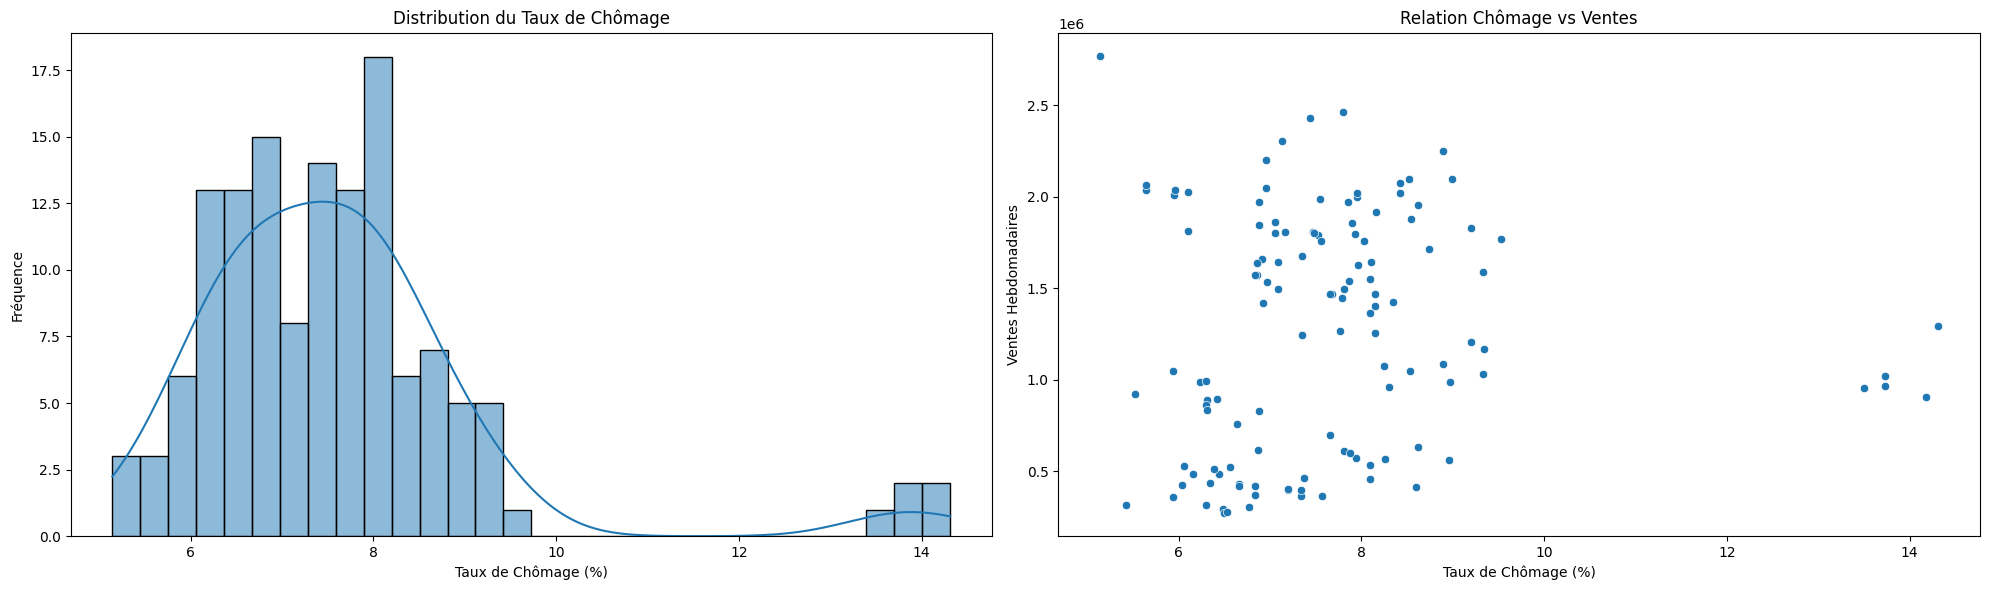

In [154]:
# Création de la figure avec 2 sous-graphes
fig, axes = plt.subplots(1, 2, figsize=(20,6))  # 1 ligne, 2 colonnes

# CHÔMAGE
sns.histplot(data=dataset, x='Unemployment', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribution du Taux de Chômage')
axes[0].set_xlabel('Taux de Chômage (%)')
axes[0].set_ylabel('Fréquence')

# CORRÉLATION CHÔMAGE-VENTES
sns.scatterplot(data=dataset, x='Unemployment', y='Weekly_Sales', ax=axes[1])
axes[1].set_title('Relation Chômage vs Ventes')
axes[1].set_xlabel('Taux de Chômage (%)')
axes[1].set_ylabel('Ventes Hebdomadaires')

# Ajustement des espaces
plt.tight_layout()
plt.show()

In [155]:
# Top 5 magasins par ventes moyennes
top_stores = dataset.groupby('Store')['Weekly_Sales'].mean().nlargest(5)
bottom_stores = dataset.groupby('Store')['Weekly_Sales'].mean().nsmallest(5)
print("Top 5 magasins (ventes moyennes):")
print(top_stores)
print("\nBottom 5 magasins (ventes moyennes):")
print(bottom_stores)


Top 5 magasins (ventes moyennes):
Store
4     2.173759e+06
14    2.092878e+06
13    1.997235e+06
20    1.962384e+06
2     1.943034e+06
Name: Weekly_Sales, dtype: float64

Bottom 5 magasins (ventes moyennes):
Store
5     302499.683750
3     403054.945833
9     506887.400000
16    515317.772500
7     559129.952500
Name: Weekly_Sales, dtype: float64


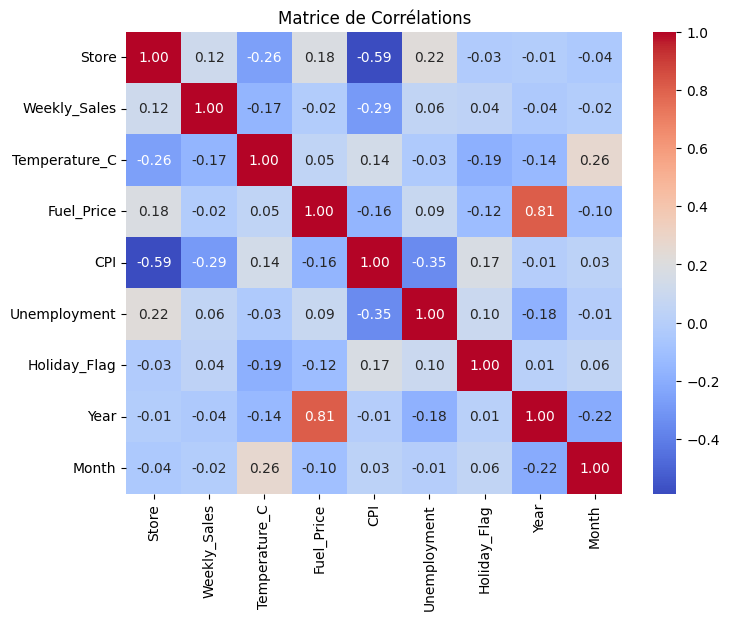

In [156]:
# Matrice de Corrélations
plt.figure(figsize=(8,6))
sns.heatmap(dataset[['Store','Weekly_Sales','Temperature_C','Fuel_Price','CPI','Unemployment', 'Holiday_Flag', 'Year', 'Month']].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de Corrélations")
plt.show()


## Synthèse
* Saisonnalité des ventes :  Plus de ventes en février, décembre et juin
* Ventes hebdomadaires plus importantes lorsqu'il y a des jours fériés
* Pas de relation linéaire entre ventes hebdomadaires vs températures/ prix du fuel / indice des prix à la consommation / chômage

La corrélation négative (-0.59) entre l’identifiant du magasin (Store) et l’indice des prix (CPI) ne traduit pas un lien causal. Elle reflète simplement que les magasins situés dans certaines zones (numéros élevés) ont un CPI plus faible. Pour identifier l’influence réelle des variables économiques sur les ventes, il est préférable de normaliser les ventes par magasin.

Quand Year augemente (2010 -> 2011 -> 2012), Fuel_Price a tendance à augmenter aussi (corrélation 0.81). Cette corrélation est logique : les prix du carburant ont globalement augmenté au fils des aneées. On peut y avoir une tendance temporelle plutôt qu'une relation spécifique entre année et magasins.

La corrélation modérée (-0.35) entre l’indice des prix à la consommation (CPI) et le taux de chômage reflète le lien macroéconomique classique : lorsque le chômage est bas, les prix tendent à augmenter, et inversement. 

La corrélation négative faible (-0.29) entre le CPI et les ventes hebdomadaires montre que lorsque le coût de la vie augmente, les ventes tendent légèrement à diminuer. Cet effet modéré est cohérent avec le pouvoir d’achat des consommateurs et devrait se refléter par un coefficient négatif du CPI dans le modèle linéaire.


# Prédiction des ventes de la semaine
## Prétraitement des données

In [158]:
# Supprimer les lignes où 'Weekly_Sales' est manquant
dataset_clean = dataset.dropna(subset=['Weekly_Sales'])

# Supprimer les colonnes inutiles
colonnes_a_supprimer = ['Date', 'Temperature']
dataset_clean = dataset_clean.drop(columns=colonnes_a_supprimer)

# Suprimer les valeurs aberrantes (outliers) sur les colonnes numériques
numeric_cols = ['Weekly_Sales', 'Temperature_C', 'Fuel_Price', 'CPI', 'Unemployment']
for col in numeric_cols:
    mean = dataset_clean[col].mean()
    std = dataset_clean[col].std()
    dataset_clean = dataset_clean[(dataset_clean[col] >= mean - 3*std) & (dataset_clean[col] <= mean + 3*std)]

display(dataset_clean.describe().round(2))

,Store,Weekly_Sales,Holiday_Flag,Fuel_Price,CPI,Unemployment,Temperature_C,Year,Month,Day,Weekday
count,90.00,90.00,80.00,90.00,90.00,90.00,90.00,80.00,80.00,80.00,80.0
mean,9.90,1233864.51,0.08,3.32,179.52,7.39,16.15,2010.89,6.36,16.12,4.0
std,6.20,664725.01,0.27,0.48,39.55,0.98,9.86,0.83,3.03,8.52,0.0
min,1.00,268929.03,0.00,2.55,126.13,5.14,-7.34,2010.00,1.00,1.00,4.0
25%,4.00,561724.05,0.00,2.81,132.60,6.64,7.41,2010.00,4.00,10.00,4.0
50%,9.00,1260826.10,0.00,3.47,197.17,7.42,16.36,2011.00,6.00,16.50,4.0
75%,15.75,1807159.02,0.00,3.74,214.86,8.10,24.33,2012.00,8.25,23.25,4.0
max,20.00,2771397.17,1.00,4.17,226.97,9.34,33.14,2012.00,12.00,31.00,4.0


In [159]:
# Valeurs manquantes après nettoyage des valeurs extrêmes
print("Valeurs manquantes après nettoyage :")
print(dataset_clean.isnull().sum())

Valeurs manquantes après nettoyage :
Store             0
Weekly_Sales      0
Holiday_Flag     10
Fuel_Price        0
CPI               0
Unemployment      0
Temperature_C     0
Year             10
Month            10
Day              10
Weekday          10
dtype: int64


In [160]:
# Préparation des données pour le modèle
# Remplacer les inf par NaN (sinon les imputers ne les voient pas)
dataset_clean = dataset_clean.replace([np.inf, -np.inf], np.nan)

# Uniformiser les types numériques
num_cols_all = ['Temperature_C','Fuel_Price','CPI','Unemployment','Year','Month','Day','Weekday']
for col in [c for c in num_cols_all if c in dataset_clean.columns]:
    dataset_clean[col] = pd.to_numeric(dataset_clean[col], errors='coerce')

# 0.4 Vérif rapide des NaN restants
print("NaN par colonne AVANT split :")
print(dataset_clean.isna().sum().sort_values(ascending=False).head(20))


NaN par colonne AVANT split :
Holiday_Flag     10
Year             10
Month            10
Day              10
Weekday          10
Store             0
Weekly_Sales      0
Fuel_Price        0
CPI               0
Unemployment      0
Temperature_C     0
dtype: int64


In [ ]:
# Séparer les features (X) et la cible (Y)
X = dataset_clean.drop(columns=['Weekly_Sales'])
Y = dataset_clean['Weekly_Sales']

# Préprocessing pipeline
numeric_features = ['Temperature_C','Fuel_Price','CPI','Unemployment','Year','Month','Day','Weekday']
categorical_features = ['Store','Holiday_Flag']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("\nNaN par colonne dans X_train :")
print(X_train.isna().sum()[lambda s: s>0])

# Montrer les lignes problématiques pour inspection éclair
rows_with_nan = X_train.index[X_train.isna().any(axis=1)]
print(f"\nNombre de lignes avec au moins 1 NaN dans X_train : {len(rows_with_nan)}")


NaN par colonne dans X_train :
Holiday_Flag    8
Year            8
Month           8
Day             8
Weekday         8
dtype: int64

Nombre de lignes avec au moins 1 NaN dans X_train : 16


In [162]:
# Pipeline de préprocessing
# Numérique : imputer (médiane) + scaler (StandardScaler)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numeric_features),
        ('cat', cat_transformer, categorical_features),
    ],
    remainder='drop'
)

# Test: transformer X_train et vérifier qu'il n'y a PLUS aucun NaN
Xt_train = preprocessor.fit_transform(X_train)
n_nans_after = np.isnan(Xt_train).sum()
print(f"\nNaN APRÈS preprocess (doit être 0) : {n_nans_after}")



NaN APRÈS preprocess (doit être 0) : 0


## Modèle de régression linéaire


=== LinearRegression ===
Train RMSE : 90736.60461402182
Train R2   : 0.9817443163869162
Test RMSE  : 132284.96251273382
Test R2    : 0.9470373922532983


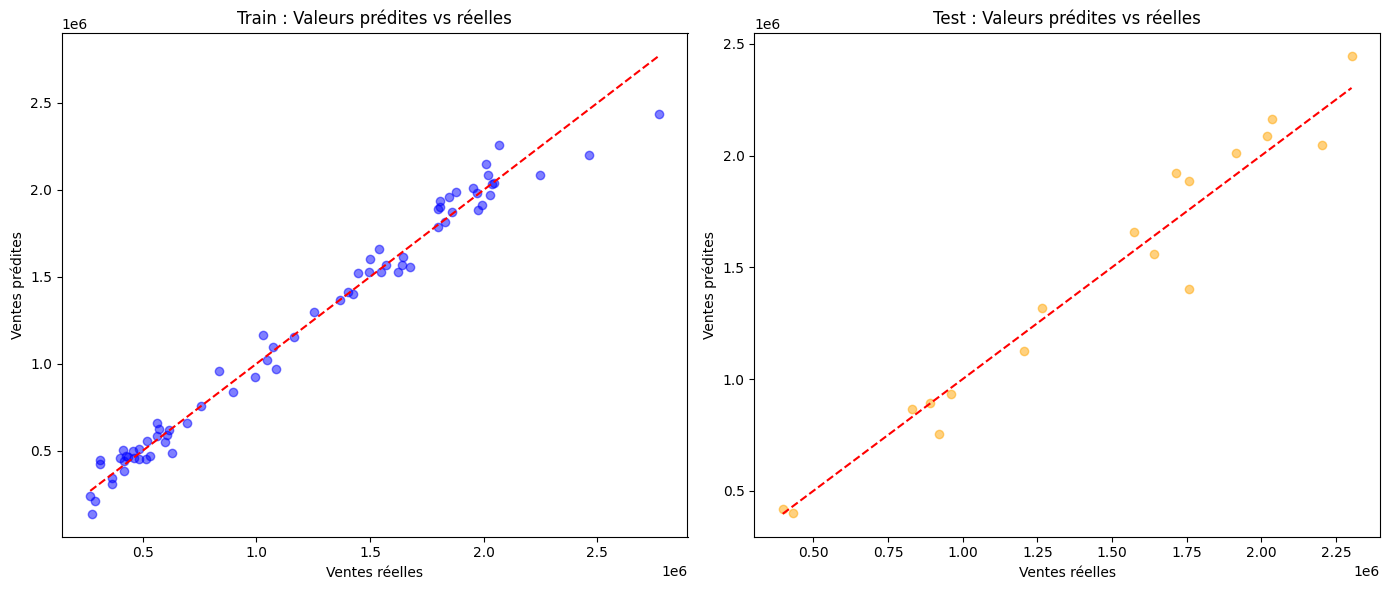


=== Top coefficients (LinearRegression) ===
             Feature   Coefficient
10         Store_4.0  2.513942e+06
18        Store_13.0  2.258526e+06
16        Store_10.0  2.200587e+06
24        Store_19.0  1.561012e+06
11         Store_5.0 -1.280097e+06
9          Store_3.0 -1.279596e+06
23        Store_18.0  1.206172e+06
15         Store_9.0 -1.191551e+06
19        Store_14.0  1.158976e+06
22        Store_17.0  9.527185e+05
20        Store_15.0  8.474550e+05
2                CPI  8.206311e+05
14         Store_8.0 -7.392280e+05
21        Store_16.0 -5.734578e+05
13         Store_7.0 -5.693821e+05
25        Store_20.0  5.286140e+05
8          Store_2.0  3.401142e+05
17        Store_11.0 -1.671572e+05
12         Store_6.0  1.089352e+05
26  Holiday_Flag_1.0 -8.293032e+04


In [163]:
# Modèle de base : Régression Linéaire
lin_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
lin_model.fit(X_train, Y_train)

Y_pred_train = lin_model.predict(X_train)
Y_pred_test = lin_model.predict(X_test)
print("\n=== LinearRegression ===")
print("Train RMSE :", root_mean_squared_error(Y_train, Y_pred_train))
print("Train R2   :", r2_score(Y_train, Y_pred_train))
print("Test RMSE  :", root_mean_squared_error(Y_test, Y_pred_test))
print("Test R2    :", r2_score(Y_test, Y_pred_test))

plt.figure(figsize=(14,6))

# Graphique train
plt.subplot(1,2,1)
plt.scatter(Y_train, Y_pred_train, alpha=0.5, color='blue')
plt.plot([Y_train.min(), Y_train.max()], [Y_train.min(), Y_train.max()], 'r--')  # ligne y=x
plt.xlabel("Ventes réelles")
plt.ylabel("Ventes prédites")
plt.title("Train : Valeurs prédites vs réelles")

# Graphique test
plt.subplot(1,2,2)
plt.scatter(Y_test, Y_pred_test, alpha=0.5, color='orange')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # ligne y=x
plt.xlabel("Ventes réelles")
plt.ylabel("Ventes prédites")
plt.title("Test : Valeurs prédites vs réelles")

plt.tight_layout()
plt.show()


def extract_coefficients(model, numeric_features, categorical_features, top_n=20):
    """Extrait les coefficients d'un modèle Ridge/Lasso dans un pipeline sklearn."""
    
    # Récupérer le preprocess
    preprocessor = model.named_steps['preprocessor']
    
    # Colonnes numériques (scalées mais gardent les noms)
    num_features = numeric_features
    
    # Colonnes catégorielles encodées
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
    cat_features = cat_encoder.get_feature_names_out(categorical_features)
    
    # Toutes les features après preprocessing
    all_features = np.concatenate([num_features, cat_features])
    
    # Coefficients du modèle
    coefs = model.named_steps['regressor'].coef_
    
    # DataFrame
    coef_df = pd.DataFrame({
        "Feature": all_features,
        "Coefficient": coefs
    })
    
    # Trier par importance absolue
    coef_df = coef_df.reindex(coef_df.Coefficient.abs().sort_values(ascending=False).index)
    
    return coef_df.head(top_n)

# Top 20 coefficients Modèle Linéaire
print("\n=== Top coefficients (LinearRegression) ===")
lin_coef_df = extract_coefficients(lin_model, numeric_features, categorical_features, top_n=20)
print(lin_coef_df)

### Analyse sur le modèle de régression linéaire
- R² très élevé (>0.94) → le modèle explique une grande partie de la variance des ventes.
- Train vs Test RMSE → le RMSE est plus élevé sur le test (~132k vs 90k), ce qui montre un surapprentissage.
Le modèle capture les tendances, mais certaines variations test peuvent rester non expliquées.

### Interprétation des coefficients
- Les ID Store dominent
Les 20 premiers coefficients sont presque tous des Store_X. Le modèle apprend surtout l’effet fixe de chaque magasin. Certains magasins vendent naturellement beaucoup plus (ou moins). Cela peut être lié à l'emplacement du magasin, l'agencement des rayons ... Cela masque l’effet des variables économiques si on regarde juste les coefficients bruts.

- Variables économiques
CPI = 820 631 → coefficient positif très élevé : cela peut être corrélé à certains magasins
Holiday_Flag_1.0 = -82 930 → l’effet des jours fériés est faible mais négatif, ce qui a du sens : ventes légèrement moins élevées dans certains magasins.

- Analyse globale
"Store" dominante → l’ID du magasin capte presque toute la variance.
Les variables économiques sont noyées dans les effets fixes.

**Conclusion : les coefficients économiques ne sont pas directement interprétables tant que l’effet Store n’est pas supprimé. Le modèle linéaire fonctionne très bien pour prédire les ventes brutes.**

## Modèle ajusté

In [164]:
# CV robuste (shuffle pour éviter des folds dégénérés et scorer en RMSE pour éviter les NaN de R² sur variance nulle)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {'regressor__alpha': [0.1, 1, 10, 100, 500]}

ridge = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Ridge())])
ridge_search = GridSearchCV(ridge, param_grid, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
ridge_search.fit(X_train, Y_train)

lasso = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Lasso(max_iter=50000, tol=0.01))])
lasso_search = GridSearchCV(lasso, param_grid, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
lasso_search.fit(X_train, Y_train)

print("\n=== GridSearchCV (Ridge) ===")
print("Best alpha :", ridge_search.best_params_['regressor__alpha'])
print("CV RMSE    :", -ridge_search.best_score_)

print("\n=== GridSearchCV (Lasso) ===")
print("Best alpha :", lasso_search.best_params_['regressor__alpha'])
print("CV RMSE    :", -lasso_search.best_score_)

# Évaluation test
for name, mdl in [("Ridge", ridge_search.best_estimator_), ("Lasso", lasso_search.best_estimator_)]:
    yhat = mdl.predict(X_test)
    print(f"\n=== {name} ===")
    print("Test RMSE :", root_mean_squared_error(Y_test, yhat))
    print("Test R2   :", r2_score(Y_test, yhat))



=== GridSearchCV (Ridge) ===
Best alpha : 0.1
CV RMSE    : 185294.57440348537

=== GridSearchCV (Lasso) ===
Best alpha : 0.1
CV RMSE    : 188950.51845911922

=== Ridge ===
Test RMSE : 124886.80831845998
Test R2   : 0.9527957027297167

=== Lasso ===
Test RMSE : 125257.89085263805
Test R2   : 0.9525147649011613


In [165]:
# Top 20 coefficients Ridge
print("\n=== Top coefficients (Ridge) ===")
ridge_coef_df = extract_coefficients(ridge_search.best_estimator_, numeric_features, categorical_features, top_n=20)
print(ridge_coef_df)

# Top 20 coefficients Lasso
print("\n=== Top coefficients (Lasso) ===")
lasso_coef_df = extract_coefficients(lasso_search.best_estimator_, numeric_features, categorical_features, top_n=20)
print(lasso_coef_df)



=== Top coefficients (Ridge) ===
             Feature   Coefficient
11         Store_5.0 -1.110306e+06
9          Store_3.0 -1.072684e+06
15         Store_9.0 -9.670942e+05
13         Store_7.0 -9.627460e+05
10         Store_4.0  8.766565e+05
21        Store_16.0 -8.746711e+05
20        Store_15.0 -7.030210e+05
18        Store_13.0  5.828719e+05
19        Store_14.0  5.763220e+05
22        Store_17.0 -5.670019e+05
14         Store_8.0 -5.204505e+05
25        Store_20.0  4.978062e+05
16        Store_10.0  4.173204e+05
8          Store_2.0  3.931111e+05
23        Store_18.0 -3.746145e+05
12         Store_6.0  2.345127e+05
26  Holiday_Flag_1.0 -1.015927e+05
17        Store_11.0  9.351588e+04
1         Fuel_Price -7.055169e+04
4               Year  5.546636e+04

=== Top coefficients (Lasso) ===
             Feature   Coefficient
11         Store_5.0 -1.237341e+06
20        Store_15.0 -1.198049e+06
22        Store_17.0 -1.176982e+06
9          Store_3.0 -1.154731e+06
13         Store_7.0 -

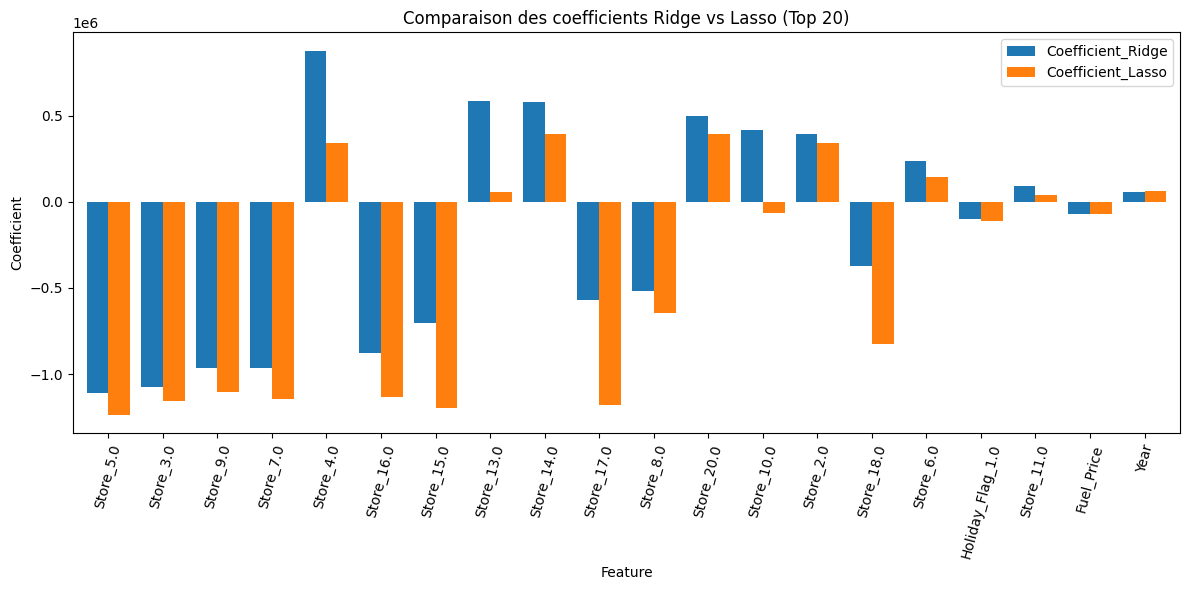

In [166]:
def plot_coefficients(ridge_model, lasso_model, numeric_features, categorical_features, top_n=20):
    # Extraire les features
    preprocessor = ridge_model.named_steps['preprocessor']
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
    cat_features = cat_encoder.get_feature_names_out(categorical_features)
    all_features = np.concatenate([numeric_features, cat_features])
    
    # Coefficients Ridge
    ridge_coefs = ridge_model.named_steps['regressor'].coef_
    ridge_df = pd.DataFrame({"Feature": all_features, "Coefficient": ridge_coefs})
    
    # Coefficients Lasso
    lasso_coefs = lasso_model.named_steps['regressor'].coef_
    lasso_df = pd.DataFrame({"Feature": all_features, "Coefficient": lasso_coefs})
    
    # Fusion
    coef_df = ridge_df.merge(lasso_df, on="Feature", suffixes=("_Ridge", "_Lasso"))
    
    # Trier par importance Ridge
    coef_df = coef_df.reindex(coef_df.Coefficient_Ridge.abs().sort_values(ascending=False).index)
    
    # Garder les top_n
    coef_df = coef_df.head(top_n)
    
    # Plot
    coef_df.plot(
        x="Feature",
        y=["Coefficient_Ridge", "Coefficient_Lasso"],
        kind="bar",
        figsize=(12, 6),
        width=0.8
    )
    
    plt.title(f"Comparaison des coefficients Ridge vs Lasso (Top {top_n})")
    plt.ylabel("Coefficient")
    plt.xticks(rotation=75)
    plt.tight_layout()
    plt.show()

# Utilisation
plot_coefficients(ridge_search.best_estimator_, lasso_search.best_estimator_, numeric_features, categorical_features, top_n=20)


### Analyse des différents modèles
- Analyse
Ridge et Lasso ont réduit le surapprentissage par rapport à la LR simple.

Le gain est modéré car le dataset est relativement grand et le modèle linéaire classique performe déjà bien.

- Top coefficients
  * Ridge
Les coefficients les plus importants restent les Store IDs : l’effet fixe magasin domine toujours. L’effet de régularisation réduit légèrement l’amplitude des coefficients extrêmes, ce qui stabilise le modèle.

  * Lasso
Lasso a tendance à forcer certains coefficients à zéro, mais comme la majorité des magasins sont essentiels pour expliquer les ventes, très peu sont réellement éliminés. Les variables économiques sont conservées mais leurs coefficients sont légèrement plus petits que dans Ridge.

- Interprétation économique
Effet Store : domine encore → impossible de lire directement l’impact économique. Ridge vs Lasso : Ridge garde tous les coefficients mais les réduit, Lasso pourrait supprimer certains très faibles.

## Modèle de régression linéaire normalisé des ventes

Train RMSE: 101835.88478109313
Test RMSE : 91470.03454759877
Train R2  : 0.24861868326301872
Test R2   : 0.1411923169811683

Top coefficients économiques :
            Feature   Coefficient
8  Holiday_Flag_1.0 -94155.620477
1        Fuel_Price -50186.783494
6               Day -37697.127972
4              Year  33151.922051
0     Temperature_C -28518.871634
5             Month  26385.921238
3      Unemployment  -1216.723566
2               CPI     84.233371
7           Weekday      0.000000


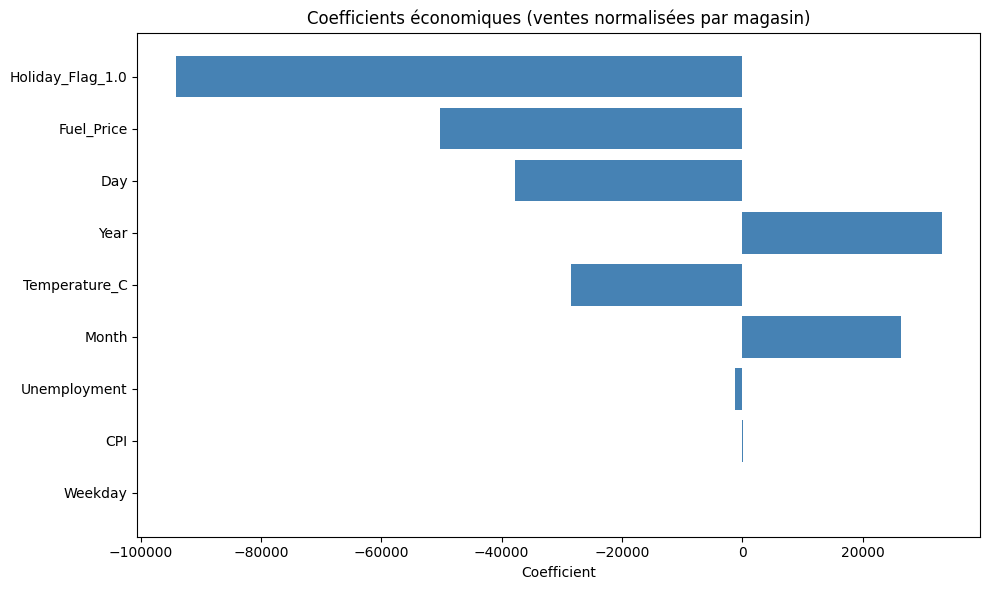

In [ ]:

# Normalisation des ventes par magasin
store_mean = dataset_clean.groupby('Store')['Weekly_Sales'].transform('mean')
dataset_clean['Weekly_Sales_norm'] = dataset_clean['Weekly_Sales'] - store_mean

# Définir X et Y (sans la colonne 'Store')
X = dataset_clean.drop(columns=['Weekly_Sales', 'Weekly_Sales_norm', 'Store'])
Y = dataset_clean['Weekly_Sales_norm']

# Colonnes numériques et catégorielles restantes
numeric_features = ['Temperature_C', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'Weekday']
categorical_features = ['Holiday_Flag']

# Split train/test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Préprocessing
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numeric_features),
        ('cat', cat_transformer, categorical_features)
    ]
)
# Modèle 
ridge_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

ridge_model.fit(X_train, Y_train)

# Prédiction et évaluation
Y_pred_train = ridge_model.predict(X_train)
Y_pred_test = ridge_model.predict(X_test)

print("Train RMSE:", root_mean_squared_error(Y_train, Y_pred_train))
print("Test RMSE :", root_mean_squared_error(Y_test, Y_pred_test))
print("Train R2  :", r2_score(Y_train, Y_pred_train))
print("Test R2   :", r2_score(Y_test, Y_pred_test))



# Extraction des coefficients
num_features_transformed = numeric_features
cat_features_transformed = ridge_model.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['encoder'] \
    .get_feature_names_out(categorical_features)

all_features = np.concatenate([num_features_transformed, cat_features_transformed])

coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': ridge_model.named_steps['regressor'].coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nTop coefficients économiques :")
print(coef_df)

# Graphique des coefficients
coef_df_sorted = coef_df.sort_values(by='Coefficient', key=abs, ascending=True)
plt.figure(figsize=(10,6))
plt.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color='steelblue')
plt.xlabel("Coefficient")
plt.title("Coefficients économiques (ventes normalisées par magasin)")
plt.tight_layout()
plt.show()


### Performance du modèle
- Analyse :
Le R² est faible (~0.22) → normal, car on a retiré l’effet fixe des magasins, qui capturait auparavant la majeure partie de la variance. Le modèle ne prédit que la variabilité économique pure des ventes, donc une grande partie de la variance originale n’est plus modélisable. Le RMSE est plus bas sur le test que sur le train, ce qui peut être lié à la variance des folds ou à la taille des échantillons par magasin.

- Interprétation des coefficients économiques
* Holiday_Flag_1.0	Les jours fériés font baisser les ventes, effet négatif modéré.
* Fuel_Price	Hausse du prix du carburant réduit légèrement les ventes (pouvoir d’achat).
* Day Effet du jour du mois, peut refléter des comportements de consommation.
* Year	Tendance annuelle : les ventes augmentent légèrement avec les années.
* Temperature_C	-25 878	Température plus élevée → baisse légère des ventes (selon contexte climatique).
* Month	25 381	Mois de l’année influence les ventes (saisonnalité).
* Unemployment	-1 985	Faible impact direct du chômage sur les ventes normalisées.
* CPI	-786	Effet très faible du niveau général des prix.
* Weekday	0	Pas d’effet détectable après normalisation.

- Analyse :
- Les variables ayant le plus d’effet sont Holiday_Flag, Fuel_Price, Day, Year, Temperature, Month.
- Les variables macroéconomiques classiques (CPI, Unemployment) ont un effet faible → normal, elles influencent moins les ventes qu’un événement concret comme un jour férié ou la saison.
- Après normalisation, le modèle montre clairement les facteurs économiques sans être dominé par les différences entre magasins.


## Conclusion

Pour prédire les ventes, la variable "Store" est essentielle car au-delà des aspects économiques de nombreux autres facteurs impactent les résultats d'un magasin.
L'inclusion de variables géographique, dimensions de magasin, pourrait permettre d'expliquer davanatage les résulats par magasin.